# A5 - 5831

This assignment focuses on advanced topics in **Association Analysis** and **Recommender Systems**, including both conceptual understanding and practical implementation.

Please ensure that your notebook is named exactly: `a5-5831.ipynb` before submission. 

You must use only the libraries and tools specified in the assignment instructions or provided on Canvas. The use of any additional packages, APIs, or external resources requires prior approval from Dr. Roy. 

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from mlxtend.preprocessing import TransactionEncoder 
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Package for Autograder 
import otter 
grader = otter.Notebook()

## Setup Cell (Not Graded)

Place this setup cell near the top of your notebook.  

This cell is provided to initialize required libraries, configurations, and any global settings needed for the assignment. It is not graded, but it must be executed before completing the rest of the notebook to ensure reproducibility and consistency.

In [2]:
pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)

ratings_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
movies_url  = "https://files.grouplens.org/datasets/movielens/ml-100k/u.item"

movies_columns = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL', 'unknown', 'action', 'adventure',
                  'animation', 'children', 'comedy', 'crime', 'documentary', 'drama', 'fantasy', 'film_noir', 'horror', 'musical',
                  'mystery', 'romance', 'sci_fi', 'thriller', 'war', 'western']

# Q1 - Association Analysis

For this problem, you will analyze a portion of the Instacart Online Grocery Shopping Dataset from 2017.  The full data set is available if you are interested.  
https://www.instacart.com/datasets/grocery-shopping-2017

The original dataset has 3 million orders.  We will work with a smaller data set.  

You will use the following files for this analysis: 

* `orders_products.csv`  
* `products.csv` 



Structure of the files, `products_orders`: 
* `order_id`: foreign key
* `product_id`: foreign key
* `add_to_cart_order`: order in which each product was added to cart
* `reordered`: 1 if this product has been ordered by this user in the past, 0 otherwise

File structure for `products`: 
* `product_id`: product identifier
* `product_name`: name of the product
* `aisle_id`: foreign key
* `department_id`: foreign key

You can connect the `product_id` with the name of the product, `product_name` in the `products.csv` file. 

## Q1(a) - Load the Data

Load the 2 data files mentioned above.  

You will need to transform this data into a boolean transaction DataFrame `orders`.  

These boolean transaction DataFrame will have rows corresponding to orders / transaction with the `order_id` as the row index.  The DataFrame will have columns corresponding to products with the `product_name` as the column names.  The DataFrame is boolean and entry [i, j] is : "False" meaning this product, j, was not purchased in order, i, and "True" means product, j, was purchased in order, i. 

The rows in the DataFrame should be in order of `order_id`.  The columns should be ordered in alphanumeric ordering of the `product_name`.

Note, you can not use the `mlxtend.TransactionEncoder` function for this because it expects data as lists of lists.  

*Hint:* several `pandas` functions such as `join`, `merge`, or `pivot` may be useful to construct the `orders` DataFrame.

Also, calculate the mean/max number of products per order for the `orders` dataset: `mean_num_prods` and `max_num_prods` 

<br>
After creating the `orders` DataFrame, capture aspects of the data: 

* `orders_num_rows` 
* `orders_num_cols` 
* `orders_col_names` 

Then, save off a slice of the data frame, `orders_small`, the first 50 rows the first 100 items. 

In [3]:
# Load and prepare the data 

prods_orders = pd.read_csv("products_orders.csv")
prods = pd.read_csv("products.csv")

df = pd.merge(prods_orders, prods, on='product_id', how='inner')

orders = (
    pd.crosstab(df["order_id"], df["product_name"]) > 0
)


orders_num_rows = orders.shape[0]
orders_num_cols = orders.shape[1]
orders_coln_names = orders.columns
orders_col_names = orders.columns


mean_num_prods = orders.sum(axis=1).mean()
max_num_prods = orders.sum(axis=1).max()


orders_small = orders.iloc[:50, :100]

orders.head()

print("Mean number of products per order: ", mean_num_prods)
print("Max number of projucts per order:  ", max_num_prods)

# clean up unneeded raw data
del prods_orders, prods

Mean number of products per order:  10.67698259187621
Max number of projucts per order:   54


In [4]:
grader.check("q1a")

q1a results: All test cases passed!

<!-- BEGIN QUESTION -->

## Q1(b) - Explore the Data 

Create a density plot showing the number of products per order using the `orders` data set.



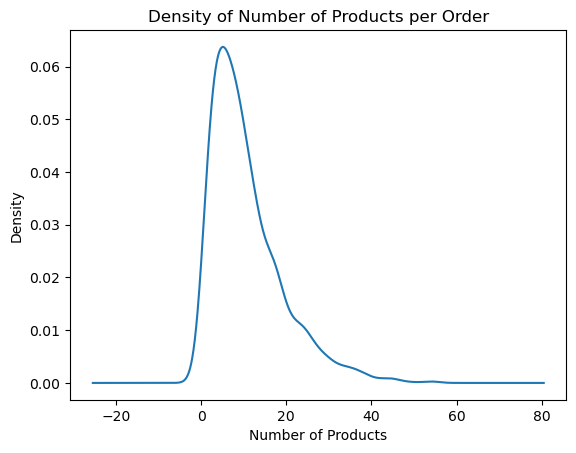

In [5]:
# Plot the number of products per order 

# find number of products per order
num_prods_per_order = orders.sum(axis=1)

# make density plot
plt.figure()
num_prods_per_order.plot(kind='density')

plt.title("Density of Number of Products per Order")
plt.xlabel("Number of Products")
plt.ylabel("Density")

plt.show()


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Q1(c) - Explore the Data, part 2 

For the `orders` dataset, create an top 15 item frequency plot, that is plot the top 15 most frequently purchased items. This should be a bar plot with items vs. frequency (relative support).

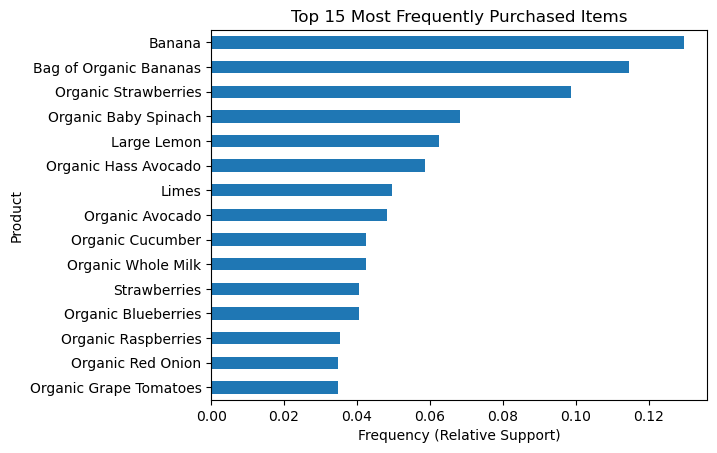

In [6]:
# Plot top 15 most frequently purchased product (by relative support) 

# find relative support
item_support = orders.mean(axis=0)

# find top 15 items
top15 = item_support.sort_values(ascending=False).head(15)


plt.figure()
top15.sort_values().plot(kind='barh')
plt.title("Top 15 Most Frequently Purchased Items")
plt.xlabel("Frequency (Relative Support)")
plt.ylabel("Product")
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Q1(d) - Explore the Data, part 3 

For the `orders` dataset, create an histogram of the number of times an item is purchased. You may want to consider using log scaling to view the data distribution more easily. 

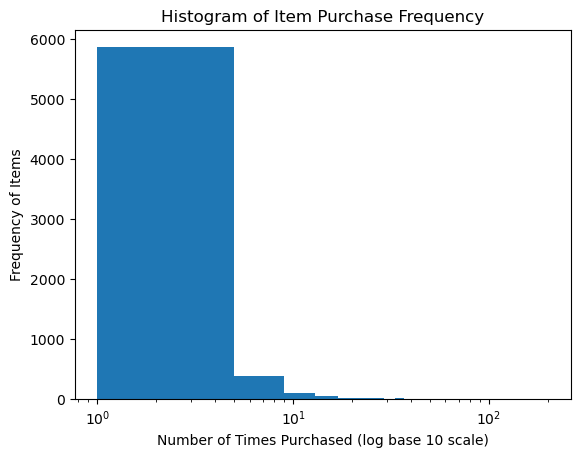

In [7]:
# Plot histogram of number of purchases per item. 
item_counts = orders.sum(axis=0)
plt.figure()
plt.hist(item_counts, bins=50)
plt.xscale('log')
plt.title("Histogram of Item Purchase Frequency")
plt.xlabel("Number of Times Purchased (log base 10 scale)")
plt.ylabel("Frequency of Items")
plt.show()

<!-- END QUESTION -->

## Q1(e) - Apriori 

For the `orders` dataset, use Apriori to find association rules, `rules` with a minimum relative support of 0.0035 and confidence of 0.5.  

In `q1e_df` sort the rules by leverage (descending order), then by confidence (in descending order)  and return the top 20 rules.

Note, the minimum support level is rather high given the information plotted in Q1(c) and Q1(d). However, this was done to avoid using too much memory (lower support values will require 15-20 GB memory). 

In [8]:
# Run Apriori as instructed

frequent_itemsets = apriori(
    orders,
    min_support=0.0035,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)
 
q1e_df = (
    rules
    .sort_values(by=["leverage", "confidence"], ascending=[False, False])
    .head(20)
)

q1e_df.iloc[0:10, [0, 1, 4, 5, 7]]


,antecedents,consequents,support,confidence,leverage
5,(Honeycrisp Apple),(Banana),0.0116,0.5000,0.0086
18,"(Organic Hass Avocado, Organic Strawberries)",(Bag of Organic Bananas),0.0077,0.5217,0.0060
25,"(Large Lemon, Organic Avocado)",(Limes),0.0058,0.5294,0.0053
26,"(Organic Avocado, Limes)",(Large Lemon),0.0058,0.5625,0.0052
6,(Roma Tomato),(Banana),0.0064,0.5263,0.0049
31,"(Organic Avocado, Organic Red Onion)",(Limes),0.0052,0.8000,0.0048
32,"(Organic Avocado, Limes)",(Organic Red Onion),0.0052,0.5000,0.0048
33,"(Organic Red Onion, Limes)",(Organic Avocado),0.0052,0.5333,0.0047
19,"(Bag of Organic Bananas, Organic Large Extra F...",(Organic Strawberries),0.0058,0.5000,0.0047
20,"(Organic Large Extra Fancy Fuji Apple, Organic...",(Bag of Organic Bananas),0.0058,0.5294,0.0045


In [9]:
grader.check("q1e")

q1e results: All test cases passed!

<!-- BEGIN QUESTION -->

## Q1(f) - Apriori, part 2

Create a scatterplot of the rules, plotting support vs. confidence colored by lift value. 


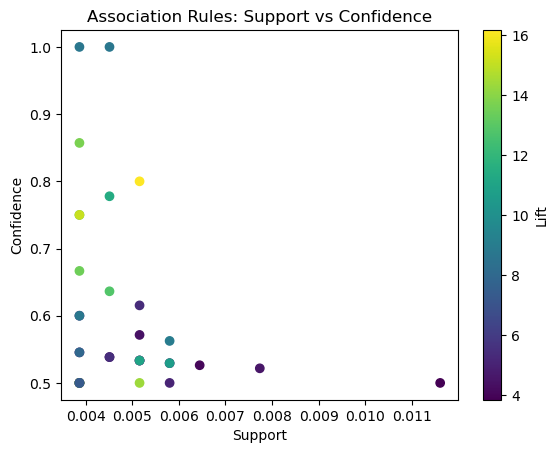

In [10]:
# Plot the results of Apriori

plt.figure()

scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"]
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs Confidence")
plt.colorbar(scatter, label="Lift")
plt.show()


<!-- END QUESTION -->

## Q1(g) - FPGrowth 

For the `orders` dataset, use FPGrowth to find association rules, `rules2` with a minimum support of 0.0035 and confidence of 0.5.

Sort the rules by conviction (descending order), then by support (descending order).  Store the top 20 rules in `q1g_df`.

Note, the relative speed for FPGrowth over Apriori.

In [11]:
# Run FPGrowth as instructed

frequent_itemsets_fp_growth = fpgrowth(
    orders,
    min_support=0.0035,
    use_colnames=True
)

rules2 = association_rules(
    frequent_itemsets_fp_growth,
    metric="confidence",
    min_threshold=0.5
)
 
q1g_df = (
    rules2
    .sort_values(by=["conviction", "support"], ascending=[False, False])
    .head(20)
)

q1g_df.iloc[0:10, [0, 1, 4, 5, 8]]

,antecedents,consequents,support,confidence,conviction
22,"(Organic Hass Avocado, Organic Large Extra Fan...",(Bag of Organic Bananas),0.0045,1.0000,inf
26,"(Organic Hass Avocado, Organic Plain Greek Who...",(Bag of Organic Bananas),0.0039,1.0000,inf
5,"(Asparagus, Limes)",(Large Lemon),0.0039,0.8571,6.5622
32,"(Organic Avocado, Organic Red Onion)",(Limes),0.0052,0.8000,4.7518
3,"(Organic Garnet Sweet Potato (Yam), Limes)",(Organic Baby Spinach),0.0045,0.7778,4.1925
16,"(Organic Cilantro, Banana)",(Limes),0.0039,0.7500,3.8014
25,"(Bag of Organic Bananas, Organic Plain Greek W...",(Organic Hass Avocado),0.0039,0.7500,3.7653
4,"(Large Lemon, Asparagus)",(Limes),0.0039,0.6667,2.8511
31,"(Large Lemon, Organic Red Onion)",(Limes),0.0045,0.6364,2.6135
2,"(Organic Garnet Sweet Potato (Yam), Organic Ha...",(Organic Baby Spinach),0.0039,0.6000,2.3291


In [12]:
grader.check("q1g")

q1g results: All test cases passed!

# Recommender Systems

## Q2(a) — Load MovieLens and Build the User–Item Matrix

In this question you will:
1. Load the MovieLens 100K ratings data (`u.data`) into a DataFrame named `ratings`.
2. Build the user–item rating matrix `R` where:
   - rows are `user_id`
   - columns are `movie_id`
   - values are `rating`
   - missing values remain as NaN

**Deliverables**
- `ratings`: DataFrame with columns `user_id, movie_id, rating, timestamp`
- `R`: user–item rating matrix as a pandas DataFrame
- Print `R.shape`

In [13]:

ratings = pd.read_csv(
    ratings_url,
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

R = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print("R shape:", R.shape)


R shape: (943, 1682)


In [14]:
grader.check("q2a")

q2a results: All test cases passed!

## Q2(b) — Sparsity and Density

Compute:
- `num_observed`: number of non-missing ratings in `R`
- `num_total`: total possible ratings (users × movies)
- `sparsity = 1 - num_observed / num_total`
- `density = num_observed / num_total`

Print both sparsity and density (rounded to 4 decimals).

**Deliverables**
- `num_observed`, `num_total`, `sparsity`, `density`

In [15]:
num_observed = R.notna().sum().sum()
num_total = R.shape[0] * R.shape[1]
density = num_observed / num_total
sparsity = 1 - num_observed / num_total

print("sparsity:", round(sparsity, 4), "density:", round(density, 4));

sparsity: 0.937 density: 0.063


In [16]:
grader.check("q2b")

q2b results: All test cases passed!

## Q3(a) — Train/Test Split (Observed Ratings)

Create two DataFrames:
- `train_ratings`: 80% of rows from `ratings`
- `test_ratings`: remaining 20%

Use `random_state=42` for reproducibility.

**Deliverables**
- `train_ratings`, `test_ratings`
- Print their sizes

In [17]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("train:", len(train_ratings), "test:", len(test_ratings));

train: 80000 test: 20000


In [18]:
grader.check("q3a")

q3a results: All test cases passed!

## Q3(b) — Baseline Bias Model

Compute:
- global mean `mu`
- user bias `b_u = mean_u - mu`
- item bias `b_i = mean_i - mu`

Then define a function:

`predict_bias(user_id, movie_id) -> float`

that returns:  μ + b_u[user] + b_i[item]
Use 0 bias if user or item is unseen.

**Deliverables**
- `mu`, `b_u`, `b_i`
- function `predict_bias`
- compute `pred_1_50 = predict_bias(1, 50)`

In [19]:
mu = train_ratings["rating"].mean()

user_means = train_ratings.groupby("user_id")["rating"].mean()
item_means = train_ratings.groupby("movie_id")["rating"].mean()

b_u = user_means - mu
b_i = item_means - mu

def predict_bias(user_id, movie_id):
    bu = b_u.get(user_id, 0)   
    bi = b_i.get(movie_id, 0)
    return mu + bu + bi

pred_1_50 = predict_bias(1, 50)
pred_1_50;

In [20]:
grader.check("q3b")

q3b results: All test cases passed!

## Q4(a) — Item-Based CF: Item–Item Similarity

Build item–item cosine similarity matrix on MovieLens.

Steps:
1. Create `R_filled = R.fillna(0)`
2. Compute cosine similarity between item vectors (columns)
3. Return as a DataFrame `S_item` indexed by movie_id

**Deliverables**
- `R_filled`
- `S_item` (shape 1682×1682)
- Print the similarity of movie 1 with movie 50 (S_item.loc[1,50])

In [31]:
R_filled = R.fillna(0)

S_item = pd.DataFrame(
    cosine_similarity(R_filled.T),
    index=R_filled.columns,
    columns=R_filled.columns
)

print("sim(1,50):", float(S_item.loc[1, 50]))

sim(1,50): 0.7345720560109746


In [33]:
grader.check("q4a")

q4a results: All test cases passed!

## Q4b — Item-Based CF Prediction (Top-k)

Implement:

`predict_ibcf(user_id, movie_id, k=20)`

Rules:
- Use similarity matrix `S_item`
- Consider only movies the user has rated
- Select top-k most similar rated movies to target
- Weighted average:
    sum(sim * rating) / sum(|sim|)
- If denominator is 0 (no neighbors), fall back to `predict_bias(user_id, movie_id)`

Compute:
- `pred_ibcf_1_50 = predict_ibcf(1, 50, k=20)`

In [44]:
def predict_ibcf(user_id, movie_id, k=20):
    # user ratings (drop NaN)
    user_row = S_item.loc[user_id].dropna()
    if user_row.empty:
        return predict_bias(user_id, movie_id)

    sims = S_item.loc[movie_id, user_row.index].copy()
    sims = sims.reindex(sims.abs().sort_values(ascending=False).head(k).index) #sorting

    num = float((sims * user_row.loc[sims.index]).sum())
    den = float(np.abs(sims).sum())

    if den == 0.0:
        return predict_bias(user_id, movie_id)
    return num / den

pred_ibcf_1_50 = predict_ibcf(1, 50, k=20)
pred_ibcf_1_50

0.6264954365366149

In [45]:
grader.check("q4b")

q4b results: All test cases passed!

## Q4c — Adjusted Cosine Similarity (User Mean-Centering)

Compute adjusted cosine similarity between items:

1. For each user, subtract that user's mean rating (computed over observed ratings)
2. Fill missing centered values with 0
3. Compute cosine similarity between item vectors → `S_adj`

Deliverables:
- `R_centered`
- `S_adj`
- Compare `S_item.loc[1,50]` vs `S_adj.loc[1,50]`
- Markdown: explain why adjusted cosine reduces user rating-scale bias

In [50]:
user_mean_R = R.mean(axis=1, skipna=True)
R_centered = R.sub(user_mean_R, axis=0)

R_centered_filled = R_centered.fillna(0)

S_adj = pd.DataFrame(
    cosine_similarity(R_centered_filled.T),
    index=R_centered_filled.columns,
    columns=R_centered_filled.columns
)

cmp_item = float(S_item.loc[1, 50])
cmp_adj  = float(S_adj.loc[1, 50])
print("cosine:", cmp_item, "adjusted:", cmp_adj)

cosine: 0.7345720560109746 adjusted: 0.2354258718724732


In [52]:
grader.check("q4c")

q4c results: All test cases passed!

## Q5(a) — Truncated SVD (k=30) and Reconstruction

Steps:
1. Fill missing with 0: `R_filled`
2. Fit `TruncatedSVD(n_components=30, random_state=42)`
3. Let `U = svd.fit_transform(R_filled)` and `Vt = svd.components_`
4. Reconstruct: `R_hat = U @ Vt`
5. Store as DataFrame `R_hat_df` with same index/columns as `R`

Deliverables:
- `svd`, `U`, `Vt`, `R_hat_df`
- print explained variance ratio sum

In [53]:
svd = TruncatedSVD(n_components=30, random_state=42)

U = svd.fit_transform(R_filled)
Vt = svd.components_

R_hat = U @ Vt
R_hat_df = pd.DataFrame(R_hat, index=R.index, columns=R.columns)

print("EVR sum:", float(svd.explained_variance_ratio_.sum()))

EVR sum: 0.45532200439544296


In [54]:
grader.check("q5a")

q5a results: All test cases passed!

## Q5b — Top-N (N=10) Recommendations + Popularity (Novelty Proxy)

For `user_id=1`:
1. Recommend top 10 unrated movies using SVD predictions `R_hat_df`
2. Store recommended movie_ids in `top10_svd`
3. Compute popularity of each movie = number of ratings in `ratings` for that movie
4. Compute `avg_popularity_top10`

Deliverables:
- `top10_svd` (list of 10 movie_ids)
- `avg_popularity_top10` (float)
- Markdown: briefly interpret whether the system tends to recommend popular items

In [151]:
user_id = 1

user_scores = R.iloc[:, user_id - 1]
rated_items = user_scores[user_scores.notna()]

unrated_items = R.iloc[:, user_id - 1].isna()

top10_svd = R_hat_df.iloc[:, user_id - 1][unrated_items].sort_values(ascending=False).head(10).index.tolist()

popularity = ratings.groupby(ratings["movie_id"]).size()
avg_popularity_top10 = float(popularity[top10_svd].mean())

top10_svd, avg_popularity_top10

([233, 452, 844, 862, 119, 85, 373, 840, 14, 834], 61.2)

In [152]:
grader.check("q5b")

q5b results: All test cases passed!

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

**NOTE** the submission must be run on the campus linux machines.  See the instruction in the Canvas assignment.

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False)